# 06. Robustness and speed of adjustment
Extra checks on the results of notebooks 02 and 03: the step from Brent to the ENSE reference price, the results without 2022, the week by week response to a cost change and an error correction model.

In [1]:
# Import the libraries
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# Load weekly Brent and the weekly ENSE reference prices
brent = pd.read_csv("../data/processed/brent_eur_weekly.csv", parse_dates=["date"])
ense = pd.read_csv("../data/processed/ense_retail_margins.csv", parse_dates=["date"])

# Move Brent dates from Sunday to Monday so both series refer to the same week
brent["date"] = brent["date"] + pd.Timedelta(days=1)
df = pd.merge(brent[["date", "brent_eur_litre"]], ense[["date", "gasoline_ref", "diesel_ref"]], on="date")
print(len(df), "weeks")

395 weeks


## From Brent to the ENSE reference price
Is there an asymmetry in refining and wholesale, before the petrol stations?

In [2]:
# Asymmetry test from Brent to the ENSE reference price (refining and wholesale stage)
results = []

for fuel_name in ["gasoline", "diesel"]:
    # Weekly change in Brent, split into rises and falls
    d_brent = df["brent_eur_litre"].diff()
    df["up"] = d_brent.clip(lower=0)
    df["down"] = d_brent.clip(upper=0)

    # The same changes in the previous three weeks
    for lag in [1, 2, 3]:
        df[f"up_lag{lag}"] = df["up"].shift(lag)
        df[f"down_lag{lag}"] = df["down"].shift(lag)

    # Weekly change in the reference price and last week's change
    df["d_ref"] = df[f"{fuel_name}_ref"].diff()
    df["d_ref_lag1"] = df["d_ref"].shift(1)

    # Regression with HAC standard errors
    formula = "d_ref ~ up + up_lag1 + up_lag2 + up_lag3 + down + down_lag1 + down_lag2 + down_lag3 + d_ref_lag1"
    model = smf.ols(formula, data=df).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

    # Long run pass-through of rises and falls
    rho = model.params["d_ref_lag1"]
    sum_up = model.params["up"] + model.params["up_lag1"] + model.params["up_lag2"] + model.params["up_lag3"]
    sum_down = model.params["down"] + model.params["down_lag1"] + model.params["down_lag2"] + model.params["down_lag3"]
    lr_up = sum_up / (1 - rho)
    lr_down = sum_down / (1 - rho)

    # Symmetry test: are rises and falls passed on equally?
    test = model.f_test("up + up_lag1 + up_lag2 + up_lag3 = down + down_lag1 + down_lag2 + down_lag3")

    results.append({
        "fuel": fuel_name,
        "lr_up": round(lr_up, 2),
        "lr_down": round(lr_down, 2),
        "p_value": round(float(test.pvalue), 3),
        "r2": round(model.rsquared, 2),
        "n": int(model.nobs),
    })

# Save and show the results
results = pd.DataFrame(results)
results.to_csv("../data/processed/rockets_feathers_brent_to_ense.csv", index=False)
results

,fuel,lr_up,lr_down,p_value,r2,n
0,gasoline,0.99,1.10,0.722,0.47,391
1,diesel,1.48,1.06,0.179,0.53,391


## Every step of the price chain, with and without 2022

In [3]:
# Add the pump prices to the table with Brent and the reference price
df = pd.merge(brent[["date", "brent_eur_litre"]], ense, on="date")

# Function that runs the asymmetric model for one cost, one price and one sample
def asymmetry_test(cost, price, sample):
    data = df.copy()

    # Weekly change in the cost, split into rises and falls, plus three lags
    d_cost = data[cost].diff()
    data["up"] = d_cost.clip(lower=0)
    data["down"] = d_cost.clip(upper=0)
    for lag in [1, 2, 3]:
        data[f"up_lag{lag}"] = data["up"].shift(lag)
        data[f"down_lag{lag}"] = data["down"].shift(lag)

    # Weekly change in the price and last week's change
    data["d_p"] = data[price].diff()
    data["d_p_lag1"] = data["d_p"].shift(1)

    # Keep only the weeks of the chosen sample and run the regression
    data = data[sample]
    formula = "d_p ~ up + up_lag1 + up_lag2 + up_lag3 + down + down_lag1 + down_lag2 + down_lag3 + d_p_lag1"
    model = smf.ols(formula, data=data).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

    # Long run pass-through and symmetry test
    rho = model.params["d_p_lag1"]
    sum_up = model.params["up"] + model.params["up_lag1"] + model.params["up_lag2"] + model.params["up_lag3"]
    sum_down = model.params["down"] + model.params["down_lag1"] + model.params["down_lag2"] + model.params["down_lag3"]
    test = model.f_test("up + up_lag1 + up_lag2 + up_lag3 = down + down_lag1 + down_lag2 + down_lag3")

    return {
        "lr_up": round(sum_up / (1 - rho), 2),
        "lr_down": round(sum_down / (1 - rho), 2),
        "p_value": round(float(test.pvalue), 3),
        "n": int(model.nobs),
    }

In [4]:
# The three stages of the price chain and the two samples
stages = [
    ("Brent to pump", "brent_eur_litre", "without_tax"),
    ("Brent to ENSE", "brent_eur_litre", "ref"),
    ("ENSE to pump", "ref", "with_tax"),
]
samples = {
    "Full sample": df["date"].dt.year > 0,
    "Without 2022": df["date"].dt.year != 2022,
}

# Run every stage, for each fuel and each sample
robustness = []
for sample_name, sample in samples.items():
    for fuel_name in ["gasoline", "diesel"]:
        for stage_name, cost, price in stages:
            # Brent is the same for both fuels, the other columns depend on the fuel
            cost_col = cost if cost == "brent_eur_litre" else f"{fuel_name}_{cost}"
            price_col = f"{fuel_name}_{price}"
            result = asymmetry_test(cost_col, price_col, sample)
            result["sample"] = sample_name
            result["fuel"] = fuel_name
            result["stage"] = stage_name
            robustness.append(result)

# Save and show the results
robustness = pd.DataFrame(robustness)
robustness = robustness[["sample", "fuel", "stage", "lr_up", "lr_down", "p_value", "n"]]
robustness.to_csv("../data/processed/robustness_without_2022.csv", index=False)
robustness

,sample,fuel,stage,lr_up,lr_down,p_value,n
0,Full sample,gasoline,Brent to pump,0.88,0.84,0.863,391
1,Full sample,gasoline,Brent to ENSE,0.99,1.10,0.722,391
2,Full sample,gasoline,ENSE to pump,0.78,0.78,0.999,391
3,Full sample,diesel,Brent to pump,1.34,0.80,0.047,391
4,Full sample,diesel,Brent to ENSE,1.48,1.06,0.179,391
5,Full sample,diesel,ENSE to pump,0.90,0.85,0.368,391
6,Without 2022,gasoline,Brent to pump,0.65,0.74,0.732,340
7,Without 2022,gasoline,Brent to ENSE,0.85,0.96,0.745,340
8,Without 2022,gasoline,ENSE to pump,0.74,0.80,0.405,340
9,Without 2022,diesel,Brent to pump,1.08,0.78,0.291,340


## Week by week response to a cost change
How much of a 1 cent rise or fall in the cost has reached the price after each week.

In [5]:
# Function that returns the week by week cumulative response to a 1 cent rise and a 1 cent fall in the cost
def cumulative_response(cost, price, weeks=8):
    data = df.copy()

    # Same variables as in the asymmetric model
    d_cost = data[cost].diff()
    data["up"] = d_cost.clip(lower=0)
    data["down"] = d_cost.clip(upper=0)
    for lag in [1, 2, 3]:
        data[f"up_lag{lag}"] = data["up"].shift(lag)
        data[f"down_lag{lag}"] = data["down"].shift(lag)
    data["d_p"] = data[price].diff()
    data["d_p_lag1"] = data["d_p"].shift(1)

    # Run the regression on the full sample
    formula = "d_p ~ up + up_lag1 + up_lag2 + up_lag3 + down + down_lag1 + down_lag2 + down_lag3 + d_p_lag1"
    model = smf.ols(formula, data=data).fit(cov_type="HAC", cov_kwds={"maxlags": 4})
    rho = model.params["d_p_lag1"]

    # Add up the price change week by week after the cost change
    paths = {}
    for direction in ["up", "down"]:
        names = [direction, f"{direction}_lag1", f"{direction}_lag2", f"{direction}_lag3"]
        change = 0
        total = 0
        path = []
        for week in range(weeks + 1):
            if week < 4:
                beta = model.params[names[week]]
            else:
                beta = 0
            change = beta + rho * change
            total = total + change
            path.append(total)
        paths[direction] = path
    return paths

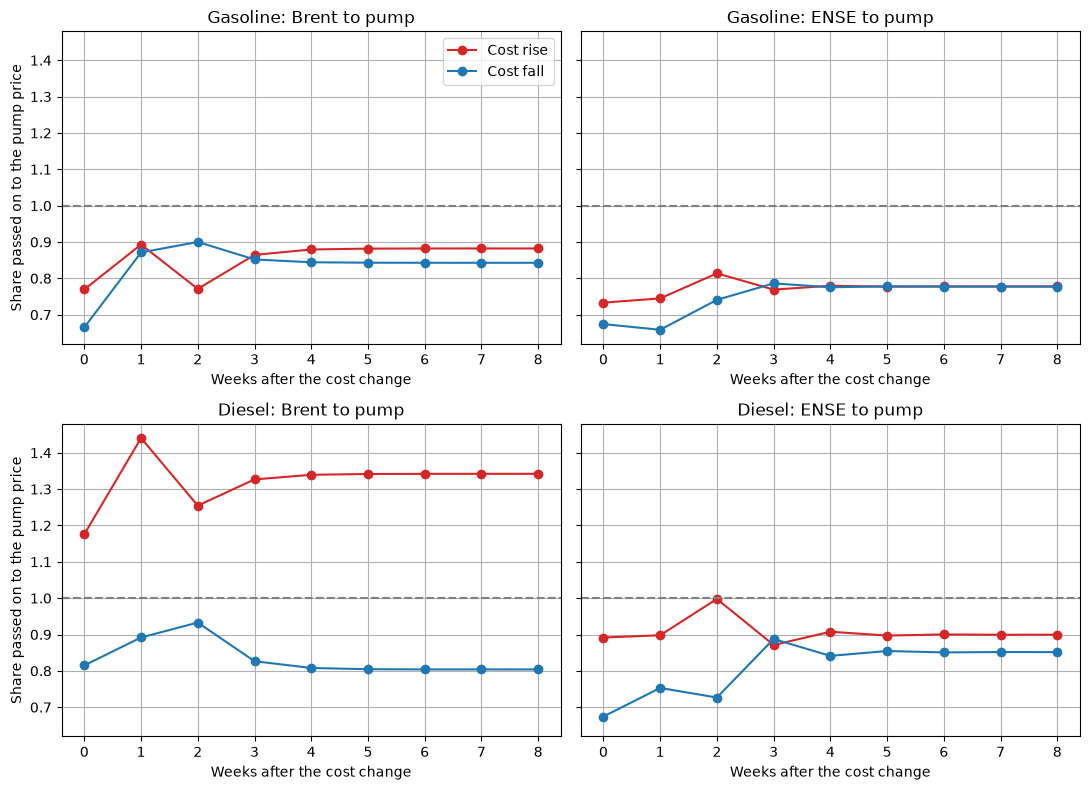

In [6]:
# Plot the cumulative responses for both fuels, against Brent and against the ENSE reference price
plot_stages = [("Brent to pump", "brent_eur_litre", "without_tax"), ("ENSE to pump", "ref", "with_tax")]
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)

for row, fuel_name in enumerate(["gasoline", "diesel"]):
    for col, (stage_name, cost, price) in enumerate(plot_stages):
        # Choose the right columns for this fuel and stage
        cost_col = cost if cost == "brent_eur_litre" else f"{fuel_name}_{cost}"
        paths = cumulative_response(cost_col, f"{fuel_name}_{price}")

        # Red line for cost rises, blue line for cost falls, dashed line at full pass-through
        ax = axes[row, col]
        ax.plot(paths["up"], color="tab:red", marker="o", label="Cost rise")
        ax.plot(paths["down"], color="tab:blue", marker="o", label="Cost fall")
        ax.axhline(1, color="grey", linestyle="--")
        ax.set_title(f"{fuel_name.capitalize()}: {stage_name}")
        ax.set_xlabel("Weeks after the cost change")
        ax.grid(True)

# Labels, legend, save and show
axes[0, 0].set_ylabel("Share passed on to the pump price")
axes[1, 0].set_ylabel("Share passed on to the pump price")
axes[0, 0].legend()
plt.tight_layout()
plt.savefig("../figures/cumulative_response.png")
plt.show()

## Error correction model
How fast does the price go back to its usual level when it is above or below it?

In [7]:
# Extra libraries for this step
import numpy as np
from statsmodels.tsa.stattools import coint

# Function that runs the error correction model for one cost and one price
def ecm_test(cost, price):
    data = df.copy()

    # Step 1: long run relationship in levels, and test if price and cost move together (cointegration)
    long_run = smf.ols(f"{price} ~ {cost}", data=data).fit()
    data["gap"] = long_run.resid
    coint_p = coint(data[price], data[cost])[1]

    # Last week's gap: price above its normal level, and price below its normal level
    data["gap_above"] = data["gap"].clip(lower=0).shift(1)
    data["gap_below"] = data["gap"].clip(upper=0).shift(1)

    # Same short run variables as before
    d_cost = data[cost].diff()
    data["up"] = d_cost.clip(lower=0)
    data["down"] = d_cost.clip(upper=0)
    for lag in [1, 2, 3]:
        data[f"up_lag{lag}"] = data["up"].shift(lag)
        data[f"down_lag{lag}"] = data["down"].shift(lag)
    data["d_p"] = data[price].diff()
    data["d_p_lag1"] = data["d_p"].shift(1)

    # Step 2: short run model with the two gap terms
    formula = "d_p ~ up + up_lag1 + up_lag2 + up_lag3 + down + down_lag1 + down_lag2 + down_lag3 + d_p_lag1 + gap_above + gap_below"
    model = smf.ols(formula, data=data).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

    # Speed of correction and half life in weeks (time to close half of the gap)
    theta_above = model.params["gap_above"]
    theta_below = model.params["gap_below"]
    test = model.f_test("gap_above = gap_below")

    return {
        "long_run_slope": round(long_run.params[cost], 2),
        "coint_p": round(coint_p, 3),
        "theta_above": round(theta_above, 3),
        "theta_below": round(theta_below, 3),
        "half_life_above": round(np.log(0.5) / np.log(1 + theta_above), 1),
        "half_life_below": round(np.log(0.5) / np.log(1 + theta_below), 1),
        "p_equal_speed": round(float(test.pvalue), 3),
    }

In [8]:
# Run the error correction model for both fuels, against Brent and against the ENSE reference price
ecm_results = []
for fuel_name in ["gasoline", "diesel"]:
    for stage_name, cost, price in plot_stages:
        cost_col = cost if cost == "brent_eur_litre" else f"{fuel_name}_{cost}"
        result = ecm_test(cost_col, f"{fuel_name}_{price}")
        result["fuel"] = fuel_name
        result["stage"] = stage_name
        ecm_results.append(result)

# Save and show the results
ecm_results = pd.DataFrame(ecm_results)
ecm_results = ecm_results[["fuel", "stage", "long_run_slope", "coint_p", "theta_above", "theta_below", "half_life_above", "half_life_below", "p_equal_speed"]]
ecm_results.to_csv("../data/processed/ecm_results.csv", index=False)
ecm_results

,fuel,stage,long_run_slope,coint_p,theta_above,theta_below,half_life_above,half_life_below,p_equal_speed
0,gasoline,Brent to pump,1.42,0.140,-0.033,-0.066,20.4,10.2,0.497
1,gasoline,ENSE to pump,0.96,0.092,-0.002,-0.129,370.7,5.0,0.244
2,diesel,Brent to pump,1.62,0.491,-0.039,-0.069,17.2,9.7,0.566
3,diesel,ENSE to pump,0.98,0.015,-0.308,-0.041,1.9,16.4,0.042


## Export for the Tableau dashboard

In [9]:
# Save the week by week responses in a long table for the Tableau dashboard
rows = []
for fuel_name in ["gasoline", "diesel"]:
    for stage_name, cost, price in plot_stages:
        cost_col = cost if cost == "brent_eur_litre" else f"{fuel_name}_{cost}"
        paths = cumulative_response(cost_col, f"{fuel_name}_{price}")
        for direction, label in [("up", "Cost rise"), ("down", "Cost fall")]:
            for week, share in enumerate(paths[direction]):
                rows.append({
                    "fuel": fuel_name.capitalize(),
                    "stage": stage_name,
                    "direction": label,
                    "week": week,
                    "share_passed_on": round(share, 3),
                })

# Save and show the first rows
tableau_response = pd.DataFrame(rows)
tableau_response.to_csv("../data/processed/tableau_cumulative_response.csv", index=False)
tableau_response.head()

,fuel,stage,direction,week,share_passed_on
0,Gasoline,Brent to pump,Cost rise,0,0.770
1,Gasoline,Brent to pump,Cost rise,1,0.893
2,Gasoline,Brent to pump,Cost rise,2,0.771
3,Gasoline,Brent to pump,Cost rise,3,0.865
4,Gasoline,Brent to pump,Cost rise,4,0.879


## How many weeks of lags?
The main model uses this week and the three weeks before. Do the results change with fewer or more weeks?

In [10]:
# Function like asymmetry_test, but with the number of weeks of lags as a choice
def lag_test(cost, price, lags):
    data = df.copy()

    # Weekly change in the cost, split into rises and falls, plus the chosen number of lags
    d_cost = data[cost].diff()
    data["up"] = d_cost.clip(lower=0)
    data["down"] = d_cost.clip(upper=0)
    up_terms = ["up"]
    down_terms = ["down"]
    for lag in range(1, lags + 1):
        data[f"up_lag{lag}"] = data["up"].shift(lag)
        data[f"down_lag{lag}"] = data["down"].shift(lag)
        up_terms.append(f"up_lag{lag}")
        down_terms.append(f"down_lag{lag}")

    # Weekly change in the price and last week's change
    data["d_p"] = data[price].diff()
    data["d_p_lag1"] = data["d_p"].shift(1)

    # Drop the first 8 weeks so every version uses the same weeks and the AIC can be compared
    data = data.iloc[8:]

    # Regression with HAC standard errors
    formula = "d_p ~ " + " + ".join(up_terms) + " + " + " + ".join(down_terms) + " + d_p_lag1"
    model = smf.ols(formula, data=data).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

    # Long run pass-through, symmetry test and AIC (lower AIC means a better balance between fit and number of terms)
    rho = model.params["d_p_lag1"]
    test = model.f_test(" + ".join(up_terms) + " = " + " + ".join(down_terms))
    return {
        "lags": lags,
        "lr_up": round(model.params[up_terms].sum() / (1 - rho), 2),
        "lr_down": round(model.params[down_terms].sum() / (1 - rho), 2),
        "p_value": round(float(test.pvalue), 3),
        "aic": round(model.aic, 1),
    }


In [11]:
# Run every stage and fuel with 1, 2, 3, 4 and 6 weeks of lags
lag_check = []
for fuel_name in ["gasoline", "diesel"]:
    for stage_name, cost, price in stages:
        cost_col = cost if cost == "brent_eur_litre" else f"{fuel_name}_{cost}"
        for lags in [1, 2, 3, 4, 6]:
            result = lag_test(cost_col, f"{fuel_name}_{price}", lags)
            result["fuel"] = fuel_name
            result["stage"] = stage_name
            lag_check.append(result)

# Save and show the results
lag_check = pd.DataFrame(lag_check)
lag_check = lag_check[["fuel", "stage", "lags", "lr_up", "lr_down", "p_value", "aic"]]
lag_check.to_csv("../data/processed/lag_length_check.csv", index=False)
print(lag_check.to_string())


        fuel          stage  lags  lr_up  lr_down  p_value     aic
0   gasoline  Brent to pump     1   0.88     0.90    0.927 -2044.0
1   gasoline  Brent to pump     2   0.81     0.85    0.858 -2043.7
2   gasoline  Brent to pump     3   0.88     0.84    0.861 -2042.2
3   gasoline  Brent to pump     4   0.94     0.84    0.657 -2039.7
4   gasoline  Brent to pump     6   1.20     0.91    0.196 -2056.5
5   gasoline  Brent to ENSE     1   1.11     1.30    0.505 -1717.7
6   gasoline  Brent to ENSE     2   0.94     1.18    0.465 -1723.9
7   gasoline  Brent to ENSE     3   0.99     1.09    0.736 -1723.0
8   gasoline  Brent to ENSE     4   1.16     1.17    0.972 -1726.3
9   gasoline  Brent to ENSE     6   1.27     1.23    0.911 -1725.8
10  gasoline   ENSE to pump     1   0.76     0.67    0.371 -2106.7
11  gasoline   ENSE to pump     2   0.79     0.75    0.572 -2115.7
12  gasoline   ENSE to pump     3   0.78     0.78    0.998 -2114.4
13  gasoline   ENSE to pump     4   0.70     0.74    0.644 -21